# Adiabatic confinement and escape in an open billiard

Figures of the paper. Run the cells under the heading of each figure after generating its data (see `README.md`). All figures are saved in `figures/`.

In [7]:
import os
import sys
from string import ascii_lowercase

import matplotlib as mpl
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Ellipse
from pynamicalsys import PlotStyler
from scipy.integrate import solve_ivp
from scipy.special import ellipe, ellipk

sys.path.insert(0, "runners")
from common import H0, L_FIGS, L_VALS, XM

data_folder = "data"
figures_folder = "figures"
os.makedirs(figures_folder, exist_ok=True)

h0 = H0
xm = XM
bbox = {"facecolor": "w", "linewidth": 0, "pad": 1, "alpha": 0.75}

In [8]:
def h(x, h0, L):
    return h0 / (1.0 + (x / L) ** 2)


def mirror_ratio(xm, L):
    return 1.0 + (xm / L) ** 2


def geometry_tag(L):
    return f"h0={h0:.5f}_L={L:.5f}_xm={xm:.5f}"

## Fig. 1

In [9]:
A_COIL = 1.0  # coil radius
D_COIL = 1.4  # coils at z = +-D_COIL
THETA0 = 0.70  # pitch angle on the midplane
RHO0 = 0.12 * A_COIL  # gyroradius on the midplane
T_END = 13.0
N_LINES = 7
Z_ARROWS = np.array([-1.30, 0.0, 1.30]) * D_COIL


def loop_field(r, z, a=A_COIL, zc=0.0):
    """(B_r, B_z) of one current loop, up to a constant factor."""
    r = np.abs(np.asarray(r, dtype=float))
    zeta = np.asarray(z, dtype=float) - zc
    small = r < 1e-9
    r = np.where(small, 1e-9, r)

    q = (a + r) ** 2 + zeta**2
    d = (a - r) ** 2 + zeta**2
    m = np.clip(4.0 * a * r / q, 0.0, 1.0 - 1e-12)
    k, e = ellipk(m), ellipe(m)

    bz = (k + e * (a**2 - r**2 - zeta**2) / d) / (2.0 * np.pi * np.sqrt(q))
    br = zeta * (-k + e * (a**2 + r**2 + zeta**2) / d) / (2.0 * np.pi * r * np.sqrt(q))

    return np.where(small, 0.0, br), bz


def field(r, z):
    br1, bz1 = loop_field(r, z, zc=-D_COIL)
    br2, bz2 = loop_field(r, z, zc=+D_COIL)
    return br1 + br2, bz1 + bz2


def a_phi(r, z, a=A_COIL, zc=0.0):
    """Azimuthal vector potential of one loop."""
    r = np.abs(np.asarray(r, dtype=float))
    small = r < 1e-9
    r = np.where(small, 1e-9, r)
    m = np.clip(4.0 * a * r / ((a + r) ** 2 + (z - zc) ** 2), 0.0, 1.0 - 1e-12)
    out = np.sqrt(a / r) / np.sqrt(m) * ((1.0 - 0.5 * m) * ellipk(m) - ellipe(m))
    return np.where(small, 0.0, out)


def flux(r, z):
    """Magnetic flux r A_phi of the pair; field lines are its contours."""
    return r * (a_phi(r, z, zc=-D_COIL) + a_phi(r, z, zc=+D_COIL))


def bz_axis(z):
    return field(0.0, z)[1]


def field_line(level, zg, rmax, nr=4000):
    """r(z) along the field line flux = level."""
    rr = np.linspace(1e-4, rmax, nr)
    out = np.empty_like(zg)
    for i, z in enumerate(zg):
        psi = flux(rr, z)
        k = np.argmax(psi)
        out[i] = np.interp(level, psi[: k + 1], rr[: k + 1]) if level <= psi[k] else np.nan
    return out


def arrow_at(ax, zline, rline, z0, ymax, step=8):
    k = int(np.argmin(np.abs(zline - z0)))
    if k + step >= zline.size:
        return
    r0, r1 = rline[k], rline[k + step]
    if not (np.isfinite(r0) and np.isfinite(r1)) or abs(r0) > ymax:
        return
    ax.annotate(
        "",
        xy=(zline[k + step], r1),
        xytext=(zline[k], r0),
        arrowprops={"arrowstyle": "-|>", "color": "0.35", "lw": 0.8, "mutation_scale": 9},
        zorder=3,
    )


def trajectory(theta0=THETA0, rho0=RHO0, t_end=T_END):
    """Integrate m dv/dt = q v x B from the midplane, between two turning points."""
    vperp, vpar = np.sin(theta0), np.cos(theta0)
    alpha = vperp / (rho0 * bz_axis(0.0))

    def rhs(_, s):
        x, y, z, vx, vy, vz = s
        r = np.hypot(x, y)
        br, bz = field(r, z)
        bx, by = (br * x / r, br * y / r) if r > 1e-12 else (0.0, 0.0)
        return [
            vx,
            vy,
            vz,
            alpha * (vy * bz - vz * by),
            alpha * (vz * bx - vx * bz),
            alpha * (vx * by - vy * bx),
        ]

    s0 = [rho0, 0.0, 0.0, 0.0, -vperp, vpar]
    sol = solve_ivp(rhs, (0.0, t_end), s0, rtol=1e-10, atol=1e-12, dense_output=True, max_step=0.01)
    t = np.linspace(0.0, t_end, 40000)
    x, _, z, _, _, vz = sol.sol(t)

    turn = np.where(np.diff(np.sign(vz)) != 0)[0]
    i, j = turn[0], turn[1]

    return x[i : j + 1], z[i : j + 1], np.array([0, j - i])

R_mag = 2.643, theta_c = 0.6625, theta_0 = 0.7000
turning points at |z| = 1.114, B/B_0 = 2.392, 1/sin^2(theta_0) = 2.410


<Figure size 640x480 with 0 Axes>

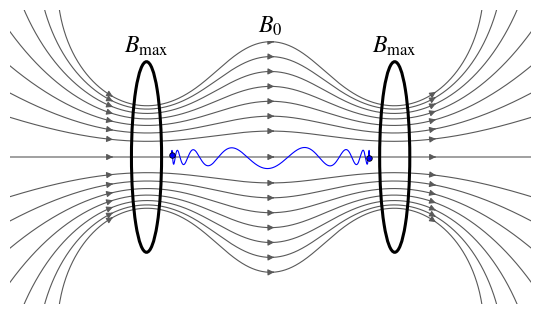

In [10]:
ps = PlotStyler(fontsize=17)
ps.apply_style()

zg = np.linspace(-2.1 * D_COIL, 2.1 * D_COIL, 1100)
rmag = bz_axis(D_COIL) / bz_axis(0.0)
r_bulge = A_COIL * np.sqrt(rmag)
ymax = 1.02 * r_bulge

fig, ax = plt.subplots(figsize=(6.0, 3.0))

zeros = np.zeros_like(zg)
ax.plot(zg, zeros, color="0.35", lw=0.8, zorder=2)
for z0 in Z_ARROWS:
    arrow_at(ax, zg, zeros, z0, ymax)

levels = flux(np.linspace(0.18, 0.80, N_LINES) * r_bulge, 0.0)
for lev in levels:
    r = field_line(lev, zg, rmax=1.6 * r_bulge)
    for sg in (-1.0, 1.0):
        ax.plot(zg, sg * r, color="0.35", lw=0.8, zorder=2)
        for z0 in Z_ARROWS:
            arrow_at(ax, zg, sg * r, z0, ymax)

for zc in (-D_COIL, D_COIL):
    ax.add_patch(
        Ellipse((zc, 0.0), width=0.34, height=2.15 * A_COIL, facecolor="none", edgecolor="k", lw=2.2, zorder=5)
    )

xp, zp, turn = trajectory()
ax.plot(zp, xp, "b", lw=0.8, zorder=7)
ax.plot(zp[turn], xp[turn], "o", color="b", ms=4, mec="k", mew=0.6, zorder=8)

box = {"facecolor": "w", "edgecolor": "none", "pad": 1.5}
ax.text(0.0, 1.6, "$B_0$", ha="center", va="top", bbox=box, zorder=9)
for sg in (-1.0, 1.0):
    ax.text(sg * D_COIL, 1.12 * A_COIL, "$B_{\\max}$", ha="center", va="bottom", bbox=box, zorder=9)

ax.set_xlim(zg[0], zg[-1])
ax.set_ylim(-ymax, ymax)
ax.set_aspect("equal")
ax.set_axis_off()

fig.subplots_adjust(left=0.005, right=0.995, bottom=0.01, top=0.99)
fig.savefig(f"{figures_folder}/fig1.eps", dpi=600, bbox_inches="tight")

zt = np.abs(zp[turn]).mean()
print(f"R_mag = {rmag:.3f}, theta_c = {np.arcsin(1 / np.sqrt(rmag)):.4f}, theta_0 = {THETA0:.4f}")
print(f"turning points at |z| = {zt:.3f}, B/B_0 = {bz_axis(zt) / bz_axis(0.0):.3f}, "
      f"1/sin^2(theta_0) = {1 / np.sin(THETA0) ** 2:.3f}")

## Fig. 2

<Figure size 640x480 with 0 Axes>

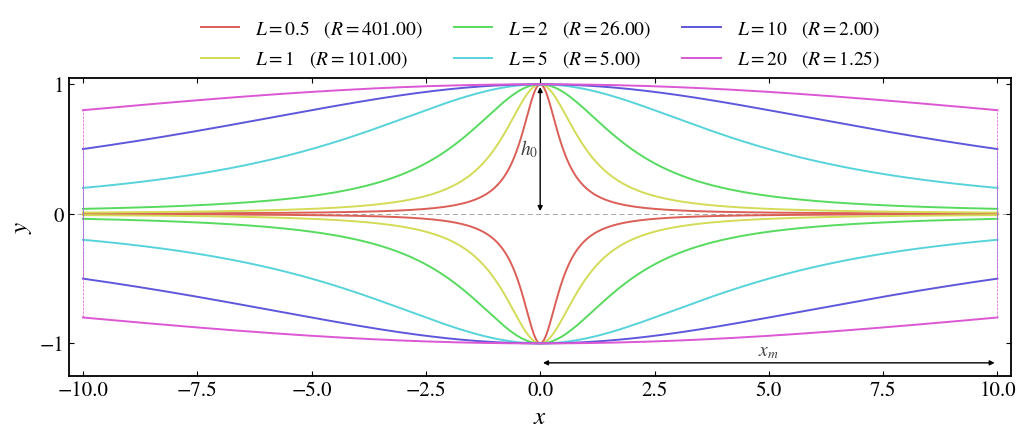

In [11]:
fontsize = 18
ps = PlotStyler(fontsize=fontsize, legend_fontsize=14)
ps.apply_style()

L_list = [0.5, 1, 2, 5, 10, 20]
colors = sns.color_palette("hls", len(L_list))
x = np.linspace(-xm, xm, 2000)

fig, ax = plt.subplots(figsize=(10, 4))

for L, color in zip(L_list, colors):
    hh = h(x, h0, L)
    R = mirror_ratio(xm, L)
    ax.plot(x, hh, color=color, lw=1.4, label=rf"$L={L:g}$   ($R={R:.2f}$)")
    ax.plot(x, -hh, color=color, lw=1.4)

    ht = h(xm, h0, L)
    for sg in (-1.0, 1.0):
        ax.plot([sg * xm, sg * xm], [-ht, ht], color=color, lw=0.5, ls="--")

ax.axhline(0.0, color="0.6", lw=0.6, ls=(0, (6, 4)), zorder=0)

ax.annotate("", xy=(0.0, h0), xytext=(0.0, 0.0),
            arrowprops=dict(arrowstyle="<|-|>", lw=1, color="k", mutation_scale=7))
ax.text(-0.05, 0.5 * h0, r"$h_0$", ha="right", va="center", color="0.25", fontsize=fontsize - 4)

ax.annotate("", xy=(xm, -1.15 * h0), xytext=(0.0, -1.15 * h0),
            arrowprops=dict(arrowstyle="<|-|>", lw=1, color="k", mutation_scale=7))
ax.text(0.5 * xm, -1.13 * h0, r"$x_m$", ha="center", va="bottom", color="0.25", fontsize=fontsize - 4)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_xlim(-1.03 * xm, 1.03 * xm)
ax.set_ylim(-1.25 * h0, 1.05 * h0)
ax.set_yticks((-1.0, 0.0, 1.0))
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=3, columnspacing=1.6,
          borderaxespad=0.0, frameon=False)

plt.subplots_adjust(left=0.053, bottom=0.12, right=0.995, top=0.865)
fig.savefig(f"{figures_folder}/fig2.eps", dpi=600)

## Fig. 3

<Figure size 640x480 with 0 Axes>

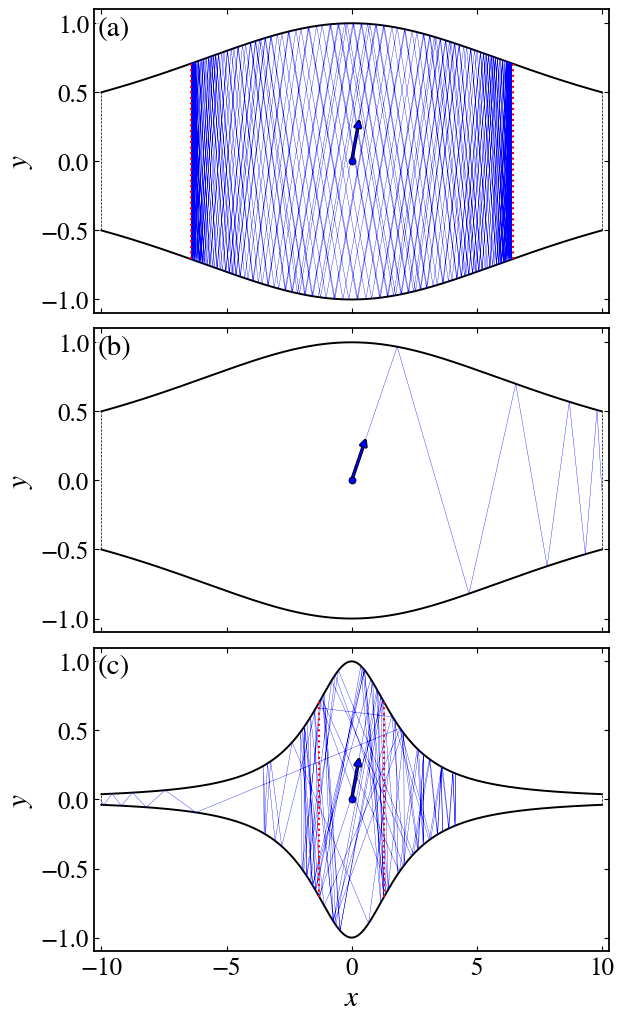

In [12]:
ps = PlotStyler(fontsize=21, legend_fontsize=14)
ps.apply_style()

L_list = [10, 10, 2]
vy0 = [0.707107, 0.469472, 0.707107]
nmax = 300
x = np.linspace(-xm, xm, 2000)

fig, ax = plt.subplots(3, 1, sharex=True, sharey=True, figsize=(6, 10))

for i, L in enumerate(L_list):
    hh = h(x, h0, L)
    ax[i].plot(x, hh, color="k", lw=1.4)
    ax[i].plot(x, -hh, color="k", lw=1.4)
    ht = h(xm, h0, L)
    for sg in (-1.0, 1.0):
        ax[i].plot([sg * xm, sg * xm], [-ht, ht], color="k", lw=0.5, ls="--")

    filename = f"{data_folder}/collisions_{geometry_tag(L)}_y0={0:.5f}_vy0={vy0[i]:.5f}_nmax={nmax}.dat"
    df = pd.read_csv(filename, header=None, sep=r"\s+")
    ax[i].plot(df[2], df[3], "b", lw=0.25)
    ax[i].set_ylabel("$y$")
    ax[i].text(0.0065, 0.915, f"({ascii_lowercase[i]})", transform=ax[i].transAxes, bbox=bbox)

    # Initial direction
    vx0 = np.sqrt(1.0 - vy0[i] ** 2)
    dy = 0.30
    ann = ax[i].annotate(
        "",
        xy=(dy * vx0 / vy0[i], dy),
        xytext=(0.0, 0.0),
        arrowprops={"arrowstyle": "-|>", "color": "b", "lw": 1.2, "mutation_scale": 10, "shrinkA": 0, "shrinkB": 0},
        zorder=4,
    )
    ann.arrow_patch.set_path_effects([pe.withStroke(linewidth=2.5, foreground="k")])
    ax[i].plot(0, 0, "bo", ms=5, mec="k", mew=0.6, zorder=5)

    # Nominal turning points, Eq. (10), shown only if inside the billiard
    xt = L * np.sqrt(1.0 / vy0[i] - 1.0)
    if xt < xm:
        ht = h(xt, h0, L)
        ax[i].plot([xt, xt], [-ht, ht], "r", ls=":", lw=1.5)
        ax[i].plot([-xt, -xt], [-ht, ht], "r", ls=":", lw=1.5)

ax[-1].set_xlabel("$x$")
ax[0].set_xlim(-1.03 * xm, 1.03 * xm)
plt.subplots_adjust(left=0.131, bottom=0.055, right=0.99, top=0.997, hspace=0.05)
plt.savefig(f"{figures_folder}/fig3.png", dpi=600)

## Fig. 4

<Figure size 640x480 with 0 Axes>

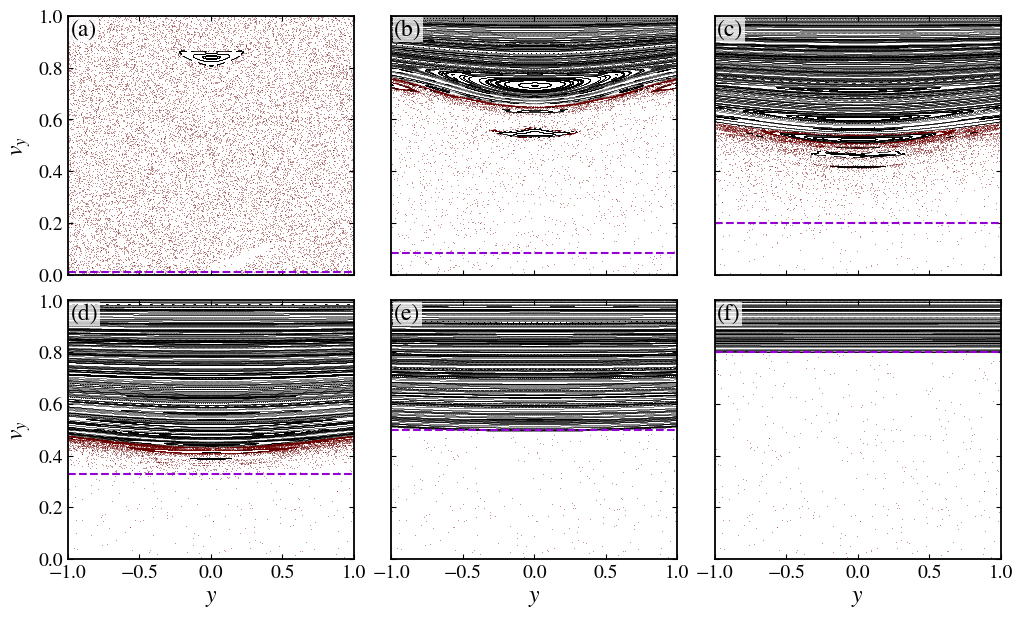

In [13]:
ps = PlotStyler(fontsize=17)
ps.apply_style()

nic = 500
ncross = 10000
seed = 1312

fig, ax = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(10, 6))

for i, L in enumerate(L_FIGS):
    filename = f"{data_folder}/section_{geometry_tag(L)}_nic={nic}_ncross={ncross}_seed={seed}.dat"
    df = pd.read_csv(filename, names=["i", "y", "vy", "side"], sep=r"\s+", header=None)

    trapped = df[df["side"] == 0]
    ax.flat[i].plot(trapped["y"], trapped["vy"], "ko", ms=0.1, mew=0)
    escaping = df[df["side"] != 0]
    ax.flat[i].plot(escaping["y"], escaping["vy"], "ro", ms=0.4, mew=0)

    ax.flat[i].axhline(1 / mirror_ratio(xm, L), c="darkviolet", lw=1.5, ls="--")
    ax.flat[i].text(0.0095, 0.926, f"({ascii_lowercase[i]})", transform=ax.flat[i].transAxes, bbox=bbox)

ax[0, 0].set_xlim(-1, 1)
ax[0, 0].set_ylim(0, 1)
for i in range(3):
    ax[-1, i].set_xlabel("$y$")
for i in range(2):
    ax[i, 0].set_ylabel("$v_y$")

plt.subplots_adjust(left=0.054, bottom=0.082, right=0.987, top=0.987, wspace=0.13, hspace=0.1)
plt.savefig(f"{figures_folder}/fig4.png", dpi=600)

## Figs. 5, 6 and 7

The escape data are read once and used by the three figures.

In [14]:
nic = 1000000
nmax = 1000000

escape_numbers = []
fraction_escape = np.zeros(len(L_VALS))
for i, L in enumerate(L_VALS):
    filename = f"{data_folder}/escape_{geometry_tag(L)}_nic={nic}_nmax={nmax}.dat"
    df = pd.read_csv(filename, header=None, sep=r"\s+", names=["y", "vy", "n", "t", "side"]).dropna()
    n = df["n"].to_numpy(dtype=np.int64)
    escape_numbers.append(n)
    fraction_escape[i] = np.mean(n < nmax)

In [15]:
def survival_probability(escape_numbers, npoints=500):
    """P(n) = Pr(n_esc >= n) on logarithmically spaced n."""
    escape_numbers = np.asarray(escape_numbers)
    n = np.unique(np.logspace(0, np.log10(escape_numbers.max()), npoints).astype(np.int64))
    P = np.array([np.mean(escape_numbers >= ni) for ni in n])
    return n, P


def median_escape_number(n, P_esc):
    """n_1/2 such that P_esc(n_1/2) = 1/2, interpolated in log n."""
    i = np.where(P_esc <= 0.5)[0][0]
    if i == 0:
        return n[0]
    x1, x2 = np.log(n[i - 1]), np.log(n[i])
    y1, y2 = P_esc[i - 1], P_esc[i]
    return np.exp(x1 + (0.5 - y1) * (x2 - x1) / (y2 - y1))


survival = []
survival_escaped = []
stats = np.zeros((2, len(L_VALS)))
for i, n_esc in enumerate(escape_numbers):
    survival.append(survival_probability(n_esc))
    escaped = n_esc[n_esc < nmax]
    n, P_esc = survival_probability(escaped)
    survival_escaped.append((n, P_esc))
    stats[:, i] = median_escape_number(n, P_esc), escaped.mean()

### Fig. 5

<Figure size 640x480 with 0 Axes>

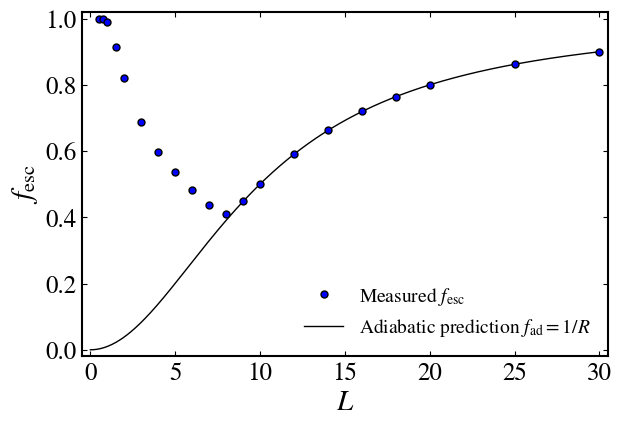

In [16]:
ps = PlotStyler(fontsize=21, axes_linewidth=1.5)
ps.apply_style()

L_cont = np.linspace(0.01, L_VALS[-1], 1000)

plt.subplots(figsize=(6, 4))
plt.plot(L_VALS, fraction_escape, "bo", label=r"Measured $f_{\rm esc}$", zorder=1)
plt.plot(L_cont, 1 / mirror_ratio(xm, L_cont), "k", label=r"Adiabatic prediction $f_{\rm ad}=1/R$", zorder=0)
plt.legend(frameon=False)
plt.xlabel(r"$L$")
plt.ylabel(r"$f_{\rm esc}$")
plt.ylim(-0.02, 1.02)
plt.xlim(-0.5, 30.5)
plt.subplots_adjust(left=0.118, bottom=0.134, right=0.995, top=0.995)
plt.savefig(f"{figures_folder}/fig5.eps", dpi=600)

### Fig. 6

<Figure size 640x480 with 0 Axes>

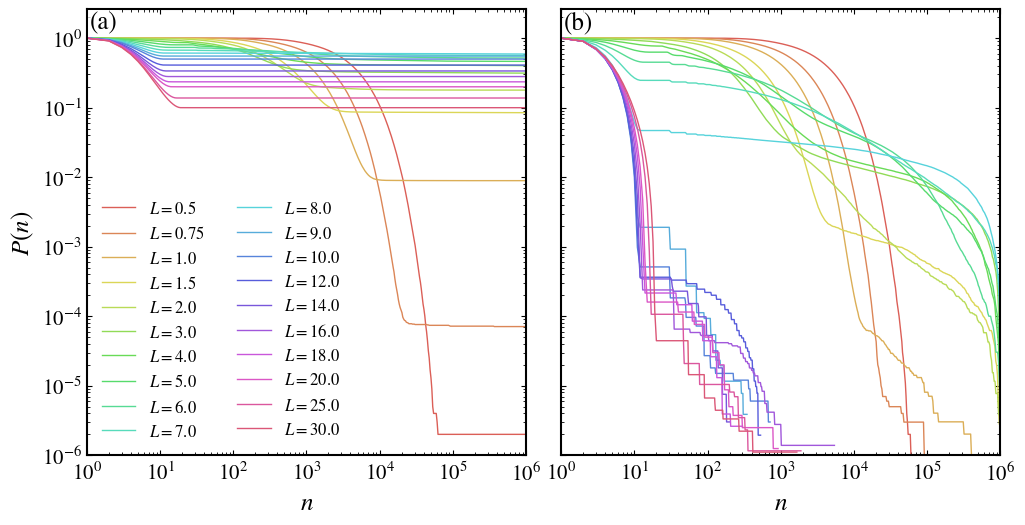

In [17]:
ps = PlotStyler(fontsize=18, axes_linewidth=1.5, legend_fontsize=12)
ps.apply_style()

fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(10, 5))
ps.set_tick_padding(ax[0], pad_x=5)
ps.set_tick_padding(ax[1], pad_x=5)

colors = sns.color_palette("hls", len(L_VALS))
for i, L in enumerate(L_VALS):
    ax[0].loglog(*survival[i], c=colors[i], label=f"$L = {L}$")
    ax[1].loglog(*survival_escaped[i], c=colors[i])

ax[0].set_xlim(1, nmax)
ax[0].set_ylim(1 / nic, 2.6e0)
ax[0].legend(loc="lower left", ncol=2, frameon=False)
ax[0].set_ylabel("$P(n)$")
for i in range(2):
    ax[i].set_xlabel("$n$")
    ax[i].text(0.0065, 0.9555, f"({ascii_lowercase[i]})", transform=ax[i].transAxes, bbox=bbox)

plt.subplots_adjust(left=0.072, bottom=0.098, right=0.9855, top=0.99, wspace=0.08)
plt.savefig(f"{figures_folder}/fig6.png", dpi=600)

### Fig. 7

<Figure size 640x480 with 0 Axes>

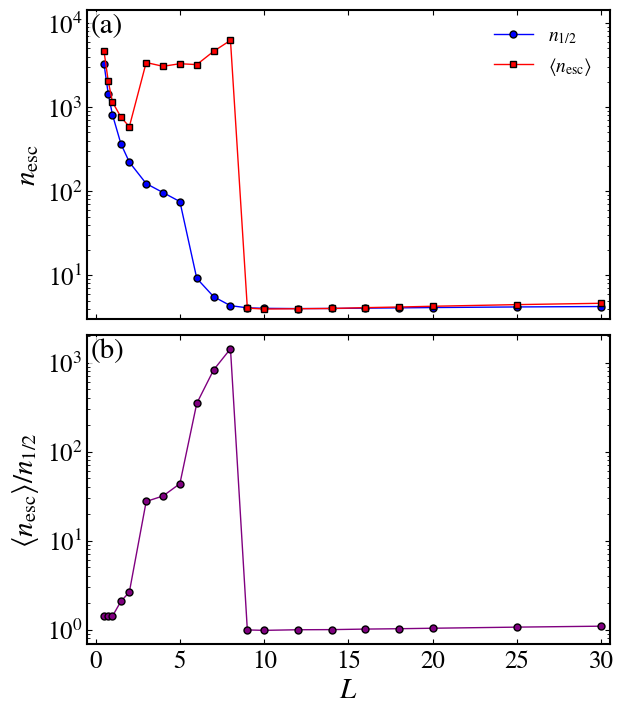

In [18]:
ps = PlotStyler(fontsize=21, axes_linewidth=1.5, legend_fontsize=14)
ps.apply_style()

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(6, 7))

ax[0].plot(L_VALS, stats[0], "bo-", label="$n_{1/2}$")
ax[0].plot(L_VALS, stats[1], "rs-", label=r"$\langle n_{\mathrm{esc}} \rangle$")
ax[0].legend(loc="upper right", frameon=False)
ax[0].set_yscale("log")
ax[0].set_ylabel(r"$n_{\rm esc}$")
ax[0].set_ylim(3e0, 1.45e4)

ax[1].plot(L_VALS, stats[1] / stats[0], "o-", c="purple")
ax[1].set_yscale("log")
ax[1].set_ylabel(r"$\langle n_{\mathrm{esc}} \rangle / n_{1/2}$")
ax[1].set_xlabel(r"$L$")
ax[1].set_xlim(-0.5, 30.5)
ax[1].set_xticks(np.arange(0, 35, 5))

for i in range(2):
    ax[i].text(0.0065, 0.926, f"({ascii_lowercase[i]})", transform=ax[i].transAxes, bbox=bbox)

plt.subplots_adjust(left=0.122, bottom=0.077, right=0.993, top=0.984, hspace=0.05)
plt.savefig(f"{figures_folder}/fig7.png", dpi=600)

## Fig. 8

<Figure size 640x480 with 0 Axes>

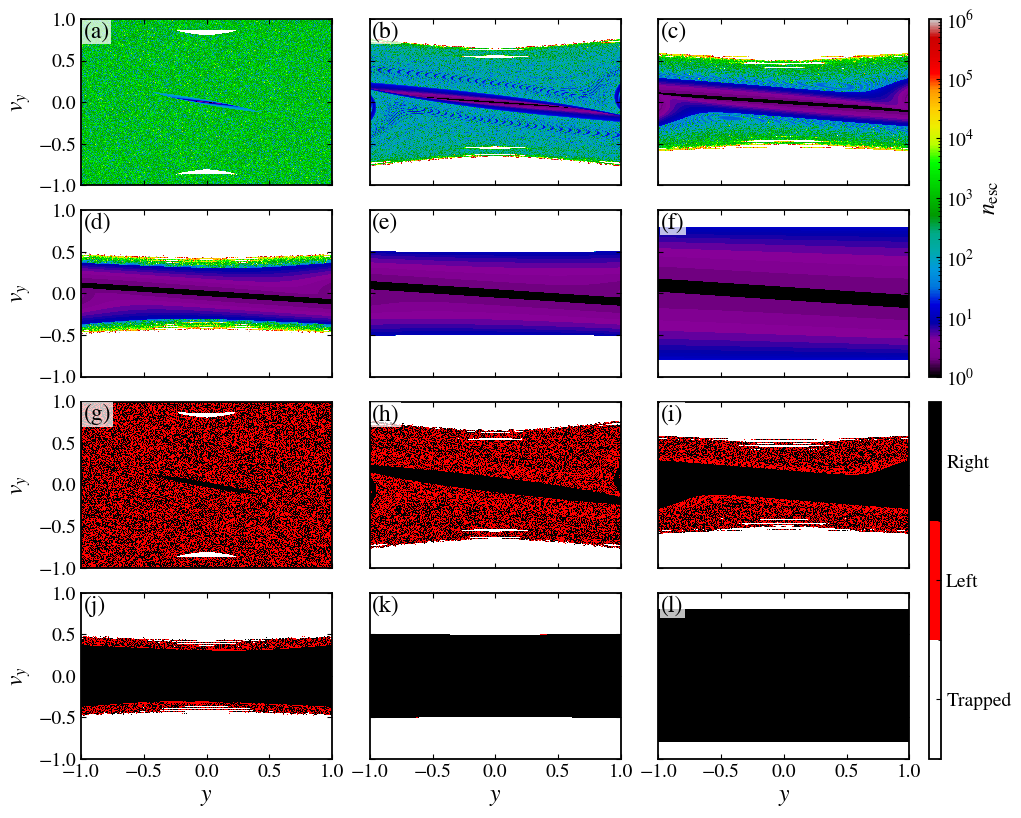

In [19]:
ps = PlotStyler(fontsize=17)
ps.apply_style()

grid_size = 1000
nmax = 1000000
window = f"yini={-1:.5f}_yend={1:.5f}_vyini={-1:.5f}_vyend={1:.5f}"

cmap = mpl.colors.ListedColormap(["white", "red", "black"])
norm = mpl.colors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

fig, ax = plt.subplots(4, 3, sharex=True, sharey=True, figsize=(10, 8))
nL = len(L_FIGS)
for i, L in enumerate(L_FIGS):
    filename = f"{data_folder}/basin_{geometry_tag(L)}_grid_size={grid_size}_{window}_nmax={nmax}.dat"
    df = pd.read_csv(filename, header=None, sep=r"\s+")
    y = df[0].to_numpy().reshape(grid_size, grid_size)
    vy = df[1].to_numpy().reshape(grid_size, grid_size)
    escape_number = df[2].to_numpy(dtype=np.float64).reshape(grid_size, grid_size)
    escape_number[escape_number == nmax] = np.nan
    escape_basin = df[4].to_numpy().reshape(grid_size, grid_size)

    hm1 = ax.flat[i].pcolormesh(y, vy, escape_number, cmap="nipy_spectral",
                                norm=mpl.colors.LogNorm(vmin=1e0, vmax=nmax))
    hm2 = ax.flat[i + nL].pcolormesh(y, vy, escape_basin, cmap=cmap, norm=norm)
    for k in (i, i + nL):
        ax.flat[k].text(0.01, 0.888, f"({ascii_lowercase[k]})", transform=ax.flat[k].transAxes, bbox=bbox)

for i in range(ax.shape[0]):
    ax[i, 0].set_ylabel("$v_y$")
for i in range(ax.shape[1]):
    ax[-1, i].set_xlabel("$y$")

plt.subplots_adjust(left=0.07, bottom=0.062, right=1.068, top=0.987, wspace=0.15, hspace=0.15)
plt.colorbar(hm1, ax=ax[:2, :3], aspect=30, pad=0.02, label=r"$n_{\mathrm{esc}}$")
cbar = plt.colorbar(hm2, ax=ax[2:, :3], aspect=30, pad=0.02, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(["Trapped", "Left", "Right"])

plt.savefig(f"{figures_folder}/fig8.png", dpi=600)

## Fig. 9

In [20]:
nic = 10000
nmax = 100000
n_runs = 10
eps_tag = f"eps_min={1e-12:.3e}_eps_max={1e-2:.3e}_n_eps=100"
eps_fit = 1e-6  # the fit uses eps < eps_fit
L_unc = [L for L in L_VALS if L <= 8]


def value_error(value, error, nsig=1):
    """Format value(error) with nsig significant digits in the error."""
    exponent = int(np.floor(np.log10(abs(error))))
    decimals = max(0, -exponent + nsig - 1)
    return f"{value:.{decimals}f}({round(error * 10**decimals)})"


f_mean = {}
alphas = np.zeros((n_runs, len(L_unc)))
for i, L in enumerate(L_unc):
    f_sum = 0.0
    for run in range(n_runs):
        filename = f"{data_folder}/uncertainty_{geometry_tag(L)}_nic={nic}_{eps_tag}_run={run}_nmax={nmax}.dat"
        df = pd.read_csv(filename, header=None, sep=r"\s+")
        eps, f = df[0].to_numpy(), df[1].to_numpy()
        f_sum = f_sum + f
        mask = eps < eps_fit
        alphas[run, i] = np.polyfit(np.log10(eps[mask]), np.log10(f[mask]), 1)[0]
    f_mean[L] = (eps, f_sum / n_runs)

<Figure size 640x480 with 0 Axes>

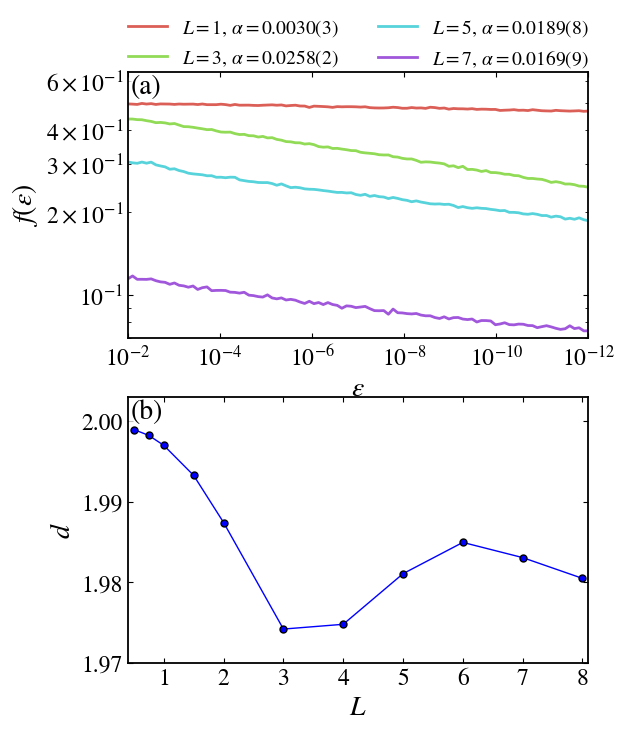

In [21]:
ps = PlotStyler(fontsize=20, legend_fontsize=14)
ps.apply_style()

fig, ax = plt.subplots(2, 1, figsize=(6, 7))
ps.set_tick_padding(ax[0], pad_x=5)

L_list = [1, 3, 5, 7]
colors = sns.color_palette("hls", len(L_list))
for L, color in zip(L_list, colors):
    alpha = alphas[:, L_unc.index(L)]
    label = rf"$L = {L}$, $\alpha = {value_error(alpha.mean(), alpha.std(ddof=1))}$"
    ax[0].loglog(*f_mean[L], c=color, lw=2, label=label)

ax[0].set_xlabel(r"$\varepsilon$")
ax[0].set_ylabel(r"$f(\varepsilon)$")
ax[0].set_ylim(7e-2, 0.65e0)
ax[0].set_xlim(1e-2, 1e-12)
ax[0].legend(ncol=2, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.27))

ax[1].plot(L_unc, 2 - alphas.mean(axis=0), "bo-")
ax[1].set_xlabel(r"$L$")
ax[1].set_ylabel("$d$")
ax[1].set_xticks(np.arange(1, 9))
ax[1].set_xlim(0.4, 8.1)
ax[1].set_ylim(1.97, 2.003)

for i in range(2):
    ax[i].text(0.006, 0.918, f"({ascii_lowercase[i]})", transform=ax[i].transAxes, bbox=bbox)

plt.subplots_adjust(left=0.1875, bottom=0.075, right=0.955, top=0.92, hspace=0.22)
plt.savefig(f"{figures_folder}/fig9.png", dpi=600)